In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# [1] Load Data

In [2]:
df_train = pd.read_csv("exp_data/span-1/train/train.csv")
df_eval = pd.read_csv("exp_data/span-1/eval/eval.csv")
df_test = pd.read_csv("exp_data/span-1/test/test.csv")

# [2] Preprocess Data

In [3]:
def preprocess_fit_transform(df_train, df_eval, df_test):
    """
    - Standardize features with mean=0, std=1 (fit on train only)
    """
    target = "c_str"
    X_train = df_train.drop(columns=[target])
    y_train = df_train[target]

    X_eval = df_eval.drop(columns=[target])
    y_eval = df_eval[target]

    X_test = df_test.drop(columns=[target])
    y_test = df_test[target]

    scaler = StandardScaler()

    X_train_s   = scaler.fit_transform(X_train)
    X_eval_s    = scaler.transform(X_eval)
    X_test_s    = scaler.transform(X_test)
    
    return X_train_s, X_eval_s, X_test_s, y_train, y_eval, y_test, scaler

In [4]:
X_train_s, X_eval_s, X_test_s, y_train, y_eval, y_test, scaler = preprocess_fit_transform(df_train, df_eval, df_test)

# [3] Model Arch

## 3.1. DNN Model

In [6]:
import tensorflow as tf
from tensorflow.keras import Input, Model, regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


def create_dnn_model(
                        input_shape: int,
                        output_units: int = 1,                 # >1 for multi-target regression
                        hidden_layers = [128, 64, 32],
                        dropout_rate: float = 0.2,
                        activation: str = "relu",
                    ) -> tf.keras.Model:
    '''
    Deep Neural Network for REGRESSION.

    Args:
        input_shape: number of input features.
        output_units: number of regression targets (default 1).
        hidden_layers: list of units per hidden layer.
        dropout_rate: dropout after each hidden layer.
        activation: hidden-layer activation.
    Returns:
        Compiled tf.keras.Model with MAE & RMSE metrics.
    '''
    # Input Layer
    inputs = Input(shape=(input_shape,))
    x = inputs
    
    # Hidden Layers
    for units in hidden_layers:
        x = Dense(units, activation=activation)(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)
    
    # Output Layer
    outputs = Dense(output_units, activation=None)(x)
    
    # Define Model
    model = Model(inputs=inputs, outputs=outputs)
    
    return model

## 3.2. Create DNN Model

In [7]:
# Construct the Deep Learning Model
dnn_model = create_dnn_model(input_shape=X_train_s.shape[1], hidden_layers=[64,32], dropout_rate=0.2)

# Print Model Summary
dnn_model.summary()

# Display the success message.
print("Model Created Successfully!")

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 8)]               0         
                                                                 
 dense (Dense)               (None, 64)                576       
                                                                 
 batch_normalization (Batch  (None, 64)                256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                            

2026-01-08 19:45:53.711073: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-08 19:45:53.713902: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## [3.3] Training Function

In [8]:
import mlflow

def train_dnn_model(model,
                    train_data, train_targets,
                    eval_data=None, eval_targets=None,
                    
                    loss = "mse",
                    learning_rate: float = 1e-3,
                    
                    validation_split: float = 0.2,              # used only if eval_data not provided
                    
                    epochs: int = 70,
                    batch_size: int = 32,
                    
                    patience: int = 10,
                    reduce_lr_patience: int = 5,
                    verbose: int = 1):
    """
    Train a TensorFlow/Keras *regression* model on tabular data (no sklearn).

    - Compiles the model with MSE loss and MAE/RMSE metrics
    - Uses EarlyStopping and ReduceLROnPlateau (on val_loss)
    - Returns (history, metrics_dict) where metrics_dict has MAE/RMSE/R² for train/eval/test
    """
    # Compile Model for Regression
    model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss=loss,
                    metrics=[
                                tf.keras.metrics.MeanAbsoluteError(name="mae"),
                                tf.keras.metrics.RootMeanSquaredError(name="rmse")
                            ]
                )
    
    # Callbacks for Improved Training
    callbacks = [
                    tf.keras.callbacks.EarlyStopping(
                                                        monitor='val_loss',
                                                        patience=patience,
                                                        restore_best_weights=True
                                                    ),
                    tf.keras.callbacks.ReduceLROnPlateau(
                                                        monitor='val_loss',
                                                        factor=0.5,
                                                        patience=reduce_lr_patience,
                                                        min_lr=1e-6
                                                    )
                ]
    
    # Start MLflow Experiment Tracking
    with mlflow.start_run():
        # 1. Log Parameters
        mlflow.log_params({
                            "learning_rate": learning_rate,
                            "epochs": epochs,
                            "batch_size": batch_size
                    })

        # 2. Train/Fit the Model
        if eval_data is not None and eval_targets is not None:
            history = model.fit(
                                    train_data, train_targets,
                                    validation_data=(eval_data, eval_targets),
                                    epochs=epochs, batch_size=batch_size,
                                    shuffle=False, callbacks=callbacks, verbose=verbose
                                )
        else:
            history = model.fit(
                                    train_data, train_targets,
                                    validation_data=validation_split,
                                    epochs=epochs, batch_size=batch_size,
                                    shuffle=False, callbacks=callbacks, verbose=verbose
                                )
        
        # 3. Log Metrics
        for epoch in range(len(history.history['loss'])):
            mlflow.log_metric("train_loss", history.history['mae'][epoch], step=epoch)
            mlflow.log_metric("train_mae", history.history['mae'][epoch], step=epoch)
            mlflow.log_metric("train_rmse", history.history['rmse'][epoch], step=epoch)

            mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)
            mlflow.log_metric("val_mae", history.history['val_mae'][epoch], step=epoch)
            mlflow.log_metric("val_rmse", history.history['val_rmse'][epoch], step=epoch)
        
        # 4. Log the Model as an Artifact
        mlflow.keras.log_model(model, "DNN Regression Model")

    return history

In [9]:
# Train the Model
mlflow.set_tracking_uri("http://127.0.0.1:5000")  # Point to the MLflow tracking server - MLflow server needs to be running
mlflow.set_experiment("DNN_Regressor")

dnn_model_training_history = train_dnn_model(
                                                model = dnn_model,
                                                
                                                train_data = X_train_s,
                                                train_targets = y_train,

                                                eval_data = X_eval_s,
                                                eval_targets = y_eval,

                                                learning_rate = 0.001,
                                                validation_split = 0.2,
                                                
                                                epochs=70,
                                                batch_size=10)

Epoch 1/70
36/36 [==============================] - 1s 9ms/step - loss: 1528.5148 - mae: 35.5780 - rmse: 39.0962 - val_loss: 1513.6794 - val_mae: 35.8701 - val_rmse: 38.9060 - lr: 0.0010
Epoch 2/70
36/36 [==============================] - 0s 4ms/step - loss: 1470.4705 - mae: 35.2140 - rmse: 38.3467 - val_loss: 1486.0884 - val_mae: 35.6471 - val_rmse: 38.5498 - lr: 0.0010
Epoch 3/70
36/36 [==============================] - 0s 3ms/step - loss: 1414.9033 - mae: 34.8550 - rmse: 37.6152 - val_loss: 1448.9946 - val_mae: 35.3508 - val_rmse: 38.0657 - lr: 0.0010
Epoch 4/70
36/36 [==============================] - 0s 3ms/step - loss: 1360.5762 - mae: 34.4150 - rmse: 36.8860 - val_loss: 1396.5990 - val_mae: 34.8767 - val_rmse: 37.3711 - lr: 0.0010
Epoch 5/70
36/36 [==============================] - 0s 3ms/step - loss: 1300.1790 - mae: 33.8606 - rmse: 36.0580 - val_loss: 1329.7976 - val_mae: 34.2071 - val_rmse: 36.4664 - lr: 0.0010
Epoch 6/70
36/36 [==============================] - 0s 3ms/step -

2026/01/08 20:06:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/08 20:06:05 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: /tmp/tmp41486q6n/model/data/model/assets


INFO:tensorflow:Assets written to: /tmp/tmp41486q6n/model/data/model/assets
2026/01/08 20:06:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run sincere-ram-495 at: http://127.0.0.1:5000/#/experiments/273344411061897600/runs/53d79ba899784d42ae9c31cbeb642843
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/273344411061897600


In [10]:
# Evaluate the Trained Model
results = dnn_model.evaluate(X_test_s, y_test, verbose=0)
metrics = dict(zip(dnn_model.metrics_names, results))

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

loss: 43.8763
mae: 5.1206
rmse: 6.6239


# 4. Plotting

## 4.1. Plotting Function

In [109]:
from matplotlib import pyplot as plt

def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    '''
    Function to plot the metrics passed to it in a graph.
    Args:
        model_training_history: A history object containing a record of training and validation 
                                loss values and metrics values at successive epochs
        metric_name_1:          The name of the first metric that needs to be plotted in the graph.
        metric_name_2:          The name of the second metric that needs to be plotted in the graph.
        plot_name:              The title of the graph.
    '''
    
    # Get metric values using metric names as identifiers.
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]
    
    # Construct a range object which will be used as x-axis (horizontal plane) of the graph.
    epochs = range(len(metric_value_1))

    # Plot the Graph.
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

    # Add title to the plot.
    plt.title(str(plot_name))

    # Add legend to the plot.
    plt.legend()

## 4.2. Plotting Curves

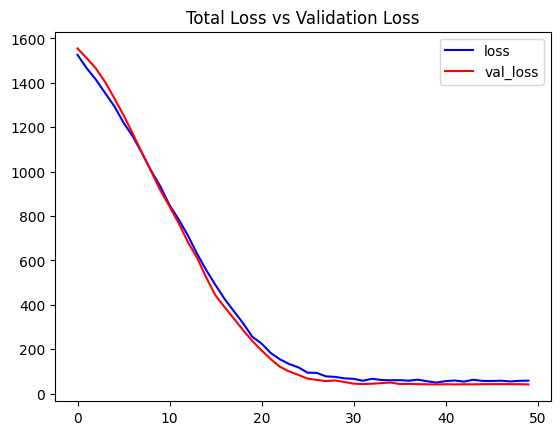

In [110]:
# Visualize the training and validation loss metrices.
plot_metric(dnn_model_training_history, 'loss', 'val_loss', 'Total Loss vs Validation Loss')

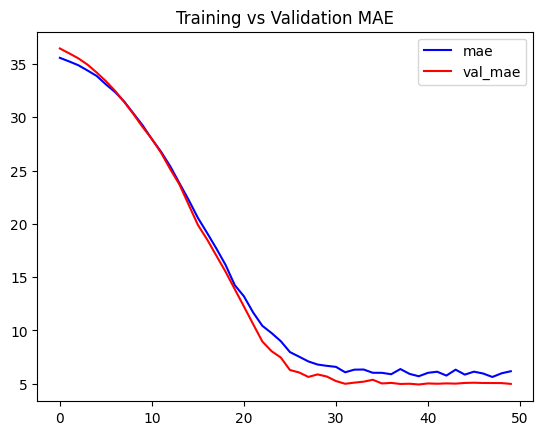

In [111]:
# Visualize the training and validation accuracy metrices.
plot_metric(dnn_model_training_history, 'mae', 'val_mae', 'Training vs Validation MAE')

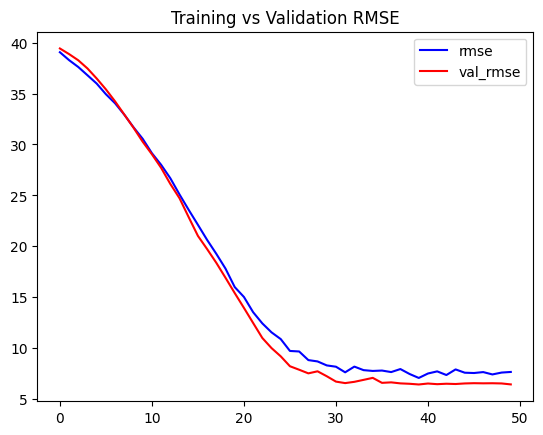

In [113]:
# Visualize the training and validation accuracy metrices.
plot_metric(dnn_model_training_history, 'rmse', 'val_rmse', 'Training vs Validation RMSE')

# 5. Save Model

In [11]:
dnn_model.save("exp_models/1_dnn_reg_model")

INFO:tensorflow:Assets written to: exp_models/1_dnn_reg_model/assets


INFO:tensorflow:Assets written to: exp_models/1_dnn_reg_model/assets
